**Step 1: Upload files**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving tmdb_5000_movies.csv.zip to tmdb_5000_movies.csv.zip


In [4]:
from google.colab import files
uploaded = files.upload()

Saving tmdb_5000_credits.csv.zip to tmdb_5000_credits.csv.zip


In [5]:
import os
print(os.listdir())

['.config', 'tmdb_5000_credits.csv.zip', 'tmdb_5000_movies.csv.zip', 'sample_data']


**Unzip files**

In [6]:
import zipfile

with zipfile.ZipFile("tmdb_5000_movies.csv.zip", 'r') as zip_ref:
    zip_ref.extractall()

with zipfile.ZipFile("tmdb_5000_credits.csv.zip", 'r') as zip_ref:
    zip_ref.extractall()

**Load in code**

In [7]:
import pandas as pd

movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

**Importing Required Libraries**

In [8]:
import pandas as pd
import numpy as np
import ast
import pickle
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD

**Loading and Merging Dataset**

In [9]:
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

movies = movies.merge(credits, on='title')
movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


**Selecting important columns (title, overview, genres, keywords, cast) required for building the recommendation system.**

In [10]:
movies = movies[['title','overview','genres','keywords','cast']]
movies.head()

,title,overview,genres,keywords,cast
0,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa..."
2,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr..."
3,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba..."
4,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c..."


**Checking missing values**

In [11]:
movies.isnull().sum()

,0
title,0
overview,3
genres,0
keywords,0
cast,0


**Removing Missing Values**

In [12]:
movies.dropna(inplace=True)

**Verification of Missing Values**

In [13]:
movies.isnull().sum()

,0
title,0
overview,0
genres,0
keywords,0
cast,0


**Checking for Duplicate Values**

In [14]:
movies.duplicated().sum()

np.int64(0)

**Removing Duplicate Values**

In [15]:
movies.drop_duplicates(inplace=True)

**Dataset Shape**

In [16]:
movies.shape

(4806, 5)

**Understanding the Genres Column**

In [17]:
movies['genres'].iloc[0]

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

**Converting JSON Data into Readable Format**

In [18]:
import ast

In [19]:
def convert(text):
    L = []
    for i in ast.literal_eval(text):
        L.append(i['name'])
    return " ".join(L)

**Applying Conversion to Genres Column**

In [20]:
movies['genres'] = movies['genres'].apply(convert)
movies[['title','genres']].head()

,title,genres
0,Avatar,Action Adventure Fantasy Science Fiction
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action
2,Spectre,Action Adventure Crime
3,The Dark Knight Rises,Action Crime Drama Thriller
4,John Carter,Action Adventure Science Fiction


**Applying Conversion to Keywords Column**

In [21]:
movies['keywords'] = movies['keywords'].apply(convert)
movies[['title','keywords']].head()

,title,keywords
0,Avatar,culture clash future space war space colony so...
1,Pirates of the Caribbean: At World's End,ocean drug abuse exotic island east india trad...
2,Spectre,spy based on novel secret agent sequel mi6 bri...
3,The Dark Knight Rises,dc comics crime fighter terrorist secret ident...
4,John Carter,based on novel mars medallion space travel pri...


**Applying Conversion to Cast Column**

In [22]:
movies['cast'] = movies['cast'].apply(convert)
movies[['title','cast']].head()

,title,cast
0,Avatar,Sam Worthington Zoe Saldana Sigourney Weaver S...
1,Pirates of the Caribbean: At World's End,Johnny Depp Orlando Bloom Keira Knightley Stel...
2,Spectre,Daniel Craig Christoph Waltz Léa Seydoux Ralph...
3,The Dark Knight Rises,Christian Bale Michael Caine Gary Oldman Anne ...
4,John Carter,Taylor Kitsch Lynn Collins Samantha Morton Wil...


**Converting Cast Column into Text Format**

In [23]:
def convert_cast(text):
    L = []
    counter = 0

    try:
        for i in ast.literal_eval(text):
            if counter < 3:
                L.append(i['name'])
                counter += 1
            else:
                break
        return " ".join(L)

    except:
        return ""

**Displaying Cleaned Cast Data**

In [24]:
movies[['cast']].head()

,cast
0,Sam Worthington Zoe Saldana Sigourney Weaver S...
1,Johnny Depp Orlando Bloom Keira Knightley Stel...
2,Daniel Craig Christoph Waltz Léa Seydoux Ralph...
3,Christian Bale Michael Caine Gary Oldman Anne ...
4,Taylor Kitsch Lynn Collins Samantha Morton Wil...


**Displaying Processed Features**

In [25]:
movies[['overview','genres','keywords','cast']].head()

,overview,genres,keywords,cast
0,"In the 22nd century, a paraplegic Marine is di...",Action Adventure Fantasy Science Fiction,culture clash future space war space colony so...,Sam Worthington Zoe Saldana Sigourney Weaver S...
1,"Captain Barbossa, long believed to be dead, ha...",Adventure Fantasy Action,ocean drug abuse exotic island east india trad...,Johnny Depp Orlando Bloom Keira Knightley Stel...
2,A cryptic message from Bond’s past sends him o...,Action Adventure Crime,spy based on novel secret agent sequel mi6 bri...,Daniel Craig Christoph Waltz Léa Seydoux Ralph...
3,Following the death of District Attorney Harve...,Action Crime Drama Thriller,dc comics crime fighter terrorist secret ident...,Christian Bale Michael Caine Gary Oldman Anne ...
4,"John Carter is a war-weary, former military ca...",Action Adventure Science Fiction,based on novel mars medallion space travel pri...,Taylor Kitsch Lynn Collins Samantha Morton Wil...


**Handling Missing Values in Overview**

In [26]:
movies['overview'] = movies['overview'].fillna('')

**Converting Text to Lowercase**

In [27]:
movies['overview'] = movies['overview'].apply(lambda x: x.lower())

**Creating Tags Column**

In [28]:
movies['tags'] = movies['overview'] + " " + movies['genres'] + " " + movies['keywords'] + " " + movies['cast']

**Displaying Title and Tags**

In [29]:
movies[['title','tags']].head()

,title,tags
0,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,Spectre,a cryptic message from bond’s past sends him o...
3,The Dark Knight Rises,following the death of district attorney harve...
4,John Carter,"john carter is a war-weary, former military ca..."


**Cleaning Tags Column**

In [30]:
movies['tags'] = movies['tags'].apply(lambda x: " ".join(x.split()))

In [31]:
movies['tags'] = movies['tags'].apply(lambda x: x.lower())
movies[['tags']].iloc[0]

,0
tags,"in the 22nd century, a paraplegic marine is di..."


**Removing Punctuation from Tags**

In [32]:
import re

def remove_punc(text):
    return re.sub(r'[^a-zA-Z0-9\s]', '', text)

movies['tags'] = movies['tags'].apply(remove_punc)

**Applying Stemming to Tags**

In [33]:
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

def stem(text):
    return " ".join([ps.stem(word) for word in text.split()])

movies['tags'] = movies['tags'].apply(stem)

**Removing Stopwords from Tags**

In [34]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in ENGLISH_STOP_WORDS])

movies['tags'] = movies['tags'].apply(remove_stopwords)

**Displaying Final Processed Tags**

In [35]:
movies['tags'].iloc[0]

'22nd centuri parapleg marin dispatch moon pandora uniqu mission becom torn follow order protect alien civil action adventur fantasi scienc fiction cultur clash futur space war space coloni societi space travel futurist romanc space alien tribe alien planet cgi marin soldier battl love affair anti war power relat mind soul 3d sam worthington zoe saldana sigourney weaver stephen lang michel rodriguez giovanni ribisi joel david moor cch pounder studi laz alonso dileep rao matt gerald sean anthoni moran jason whyte scott lawrenc kelli kilgour jame patrick pitt sean patrick murphi peter dillon kevin dorman kelson henderson david van horn jacob tomuri michael blainrozgay jon curri luke hawker woodi schultz peter mensah sonia yee jahnel curfman ilram choi kyla warren lisa roumain debra wilson chri mala taylor kibbi jodi landau juli lamm cullen b madden joseph bradi madden franki torr austin wilson sara wilson tamica washingtonmil luci briant nathan meister gerri blair matthew chamberlain pau

**Importing TF-IDF Vectorizer**

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
movies['tags'].iloc[0]

'22nd centuri parapleg marin dispatch moon pandora uniqu mission becom torn follow order protect alien civil action adventur fantasi scienc fiction cultur clash futur space war space coloni societi space travel futurist romanc space alien tribe alien planet cgi marin soldier battl love affair anti war power relat mind soul 3d sam worthington zoe saldana sigourney weaver stephen lang michel rodriguez giovanni ribisi joel david moor cch pounder studi laz alonso dileep rao matt gerald sean anthoni moran jason whyte scott lawrenc kelli kilgour jame patrick pitt sean patrick murphi peter dillon kevin dorman kelson henderson david van horn jacob tomuri michael blainrozgay jon curri luke hawker woodi schultz peter mensah sonia yee jahnel curfman ilram choi kyla warren lisa roumain debra wilson chri mala taylor kibbi jodi landau juli lamm cullen b madden joseph bradi madden franki torr austin wilson sara wilson tamica washingtonmil luci briant nathan meister gerri blair matthew chamberlain pau

**Initializing TF-IDF Vectorizer**

In [38]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

**Applying TF-IDF Vectorization**

In [39]:
vectors = tfidf.fit_transform(movies['tags']).toarray()

In [40]:
vectors.shape

(4806, 5000)

**Displaying Feature Names and Vector Values**

In [41]:
vectors[0][:20]
tfidf.get_feature_names_out()[:20]

array(['10', '12', '15', '18th', '1930', '1940', '1950', '1960', '1970',
       '1980', '19th', '20', '20th', '30', '3d', '40', '50', '60',
       'aaron', 'abandon'], dtype=object)

**Importing Cosine Similarity**

In [42]:
import difflib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [43]:
movies_data = pd.read_csv('/content/tmdb_5000_movies.csv')
print(movies_data.head())

      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "nam

In [44]:
print(movies_data.shape)

(4803, 20)


In [45]:
selected_features = ['genres', 'keywords', 'tagline', 'cast', 'director']
print(selected_features)

['genres', 'keywords', 'tagline', 'cast', 'director']


In [46]:
print(movies_data.columns)

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')


In [47]:
selected_features = ['genres', 'keywords', 'tagline', 'overview']

for feature in selected_features:
    movies_data[feature] = movies_data[feature].fillna('')

In [48]:
combined_features = (
    movies_data['genres'] + ' ' +
    movies_data['keywords'] + ' ' +
    movies_data['tagline'] + ' ' +
    movies_data['overview']
)

print(combined_features)

0       [{"id": 28, "name": "Action"}, {"id": 12, "nam...
1       [{"id": 12, "name": "Adventure"}, {"id": 14, "...
2       [{"id": 28, "name": "Action"}, {"id": 12, "nam...
3       [{"id": 28, "name": "Action"}, {"id": 80, "nam...
4       [{"id": 28, "name": "Action"}, {"id": 12, "nam...
                              ...                        
4798    [{"id": 28, "name": "Action"}, {"id": 80, "nam...
4799    [{"id": 35, "name": "Comedy"}, {"id": 10749, "...
4800    [{"id": 35, "name": "Comedy"}, {"id": 18, "nam...
4801    [] [] A New Yorker in Shanghai When ambitious ...
4802    [{"id": 99, "name": "Documentary"}] [{"id": 15...
Length: 4803, dtype: object


In [49]:
vectorizer = TfidfVectorizer()
feature_vectors = vectorizer.fit_transform(combined_features)

print(feature_vectors)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 329408 stored elements and shape (4803, 33542)>
  Coords	Values
  (0, 20199)	0.37401966585634167
  (0, 7052)	0.03603782751125524
  (0, 24034)	0.37401966585634167
  (0, 10254)	0.03534794254724929
  (0, 668)	0.04113210628113712
  (0, 10371)	0.040564503360523564
  (0, 945)	0.050415928536459306
  (0, 17557)	0.05001644052061316
  (0, 9733)	0.04751299316983126
  (0, 28322)	0.04696787599185187
  (0, 17765)	0.04710229456481479
  (0, 1041)	0.10072524707819938
  (0, 14967)	0.08613047362313951
  (0, 13789)	0.09091564915352443
  (0, 7148)	0.08341752250630552
  (0, 18424)	0.06425420582988291
  (0, 7546)	0.12467373928500694
  (0, 29500)	0.27622834060629875
  (0, 32741)	0.09964129552739377
  (0, 7555)	0.11206591760418239
  (0, 14055)	0.09720777382526347
  (0, 7784)	0.11206591760418239
  (0, 29359)	0.07638515240678383
  (0, 7843)	0.09436486524622945
  (0, 31481)	0.06836486569825767
  :	:
  (4802, 7008)	0.06342211626163982
  (4802, 16289)	0.

In [50]:
similarity = cosine_similarity(feature_vectors)

print(similarity)

[[1.         0.28774145 0.18090301 ... 0.15527507 0.01194801 0.07992733]
 [0.28774145 1.         0.18571951 ... 0.1585299  0.02552384 0.0815891 ]
 [0.18090301 0.18571951 1.         ... 0.10278695 0.01220193 0.05925512]
 ...
 [0.15527507 0.1585299  0.10278695 ... 1.         0.03751729 0.06890388]
 [0.01194801 0.02552384 0.01220193 ... 0.03751729 1.         0.04252539]
 [0.07992733 0.0815891  0.05925512 ... 0.06890388 0.04252539 1.        ]]


In [51]:
print(similarity.shape)

(4803, 4803)


**Displaying Cosine Similarity Values**

In [52]:
similarity[0][:10]

array([1.        , 0.28774145, 0.18090301, 0.24949661, 0.35200973,
       0.26868348, 0.18607728, 0.22841245, 0.20617028, 0.18343675])

**Enumerating Similarity Scores**

In [53]:
list(enumerate(similarity[0]))[:5]

[(0, np.float64(1.0000000000000002)),
 (1, np.float64(0.28774144801066065)),
 (2, np.float64(0.18090300582044316)),
 (3, np.float64(0.24949661278164353)),
 (4, np.float64(0.3520097328781146))]

**Importing Required Libraries for Machine Learning**

In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**Selecting Features and Target Variable**

In [55]:
X = movies_data.select_dtypes(include=['int64', 'float64'])
y = movies_data['revenue']

**Splitting Data into Training and Testing Sets**

In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [57]:
X = movies_data.select_dtypes(
    include=['int64', 'float64']
).fillna(0)

y = movies_data['revenue']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Checking Data Types of Training Features**

In [59]:
print(X_train.dtypes)

budget            int64
id                int64
popularity      float64
revenue           int64
runtime         float64
vote_average    float64
vote_count        int64
dtype: object


**Handling Missing Values by Removing Rows**

In [60]:
X = X.dropna()
y = y[X.index]

**Handling Missing Values using SimpleImputer**

In [61]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

**Initializing Decision Tree Regressor with Controlled Depth**

In [62]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=5)

In [63]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, max_depth=10)

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Training and Predicting using Decision Tree Regressor**

In [65]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [66]:
print("MSE:", mean_squared_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MSE: 13470544736710.414
R2 Score: 0.999482818401431


**Importing and Initializing Random Forest Regressor**

In [67]:
from sklearn.ensemble import RandomForestRegressor

In [68]:
model = RandomForestRegressor()

**Initializing Random Forest Regressor with Hyperparameters**

In [69]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

**Training Random Forest Model and Extracting Feature Importance**

In [70]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

importance = model.feature_importances_

In [71]:
pred = model.predict(X_test)

In [ ]:
print("MSE:", mean_squared_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

**Importing Libraries for K-Nearest Neighbors (KNN) Model**

In [72]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

**Applying Feature Scaling to the Entire Dataset**

In [73]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

**Training and Predicting using K-Nearest Neighbors (KNN)**

In [74]:
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [75]:
print("MSE:", mean_squared_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MSE: 18958745017193.008
R2 Score: 0.9992721070864987


**Hyperparameter Tuning using GridSearchCV**

In [76]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestRegressor(), params, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}


**Evaluating Model using Cross-Validation**

In [77]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print(scores.mean())

0.8178692371209296


**Creating a DataFrame for Actual and Predicted Values**

In [78]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred
})

print(results.head())

         Actual    Predicted
596    33561137   36301037.2
3372          5          0.0
2702    5108820    5030698.4
2473   96408652   96776580.4
8     933959197  912841285.8


**Saving and Loading the Machine Learning Model**

In [79]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [80]:
model = pickle.load(open("model.pkl", "rb"))

**Visualizing Actual vs Predicted Values**

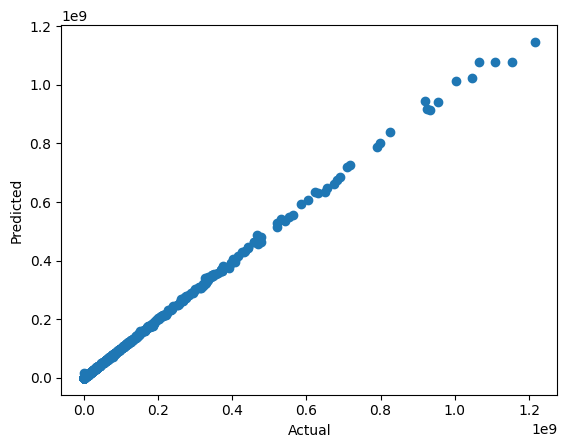

In [81]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

**Calculating Feature Importance using Permutation Importance**

In [82]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test)

importance = result.importances_mean

**Importing Libraries**

In [83]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor


from sklearn.preprocessing import StandardScaler

**Defining Features and Target Variable**

In [84]:
X = movies_data.select_dtypes(include=['int64', 'float64'])
y = movies_data['revenue']

**Handling Missing Values in Features and Target Variable**

In [85]:
X = X.fillna(X.mean())
y = y.fillna(y.mean())

**Splitting Data into Training and Testing Sets**

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Feature Scaling using StandardScaler**

In [87]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Defining Machine Learning Models**

In [88]:
models = {
    "Decision Tree": DecisionTreeRegressor(max_depth=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10),
    "KNN": KNeighborsRegressor(n_neighbors=5),

}

**Training and Evaluating Multiple Machine Learning Models**

In [89]:
results = []

for name, model in models.items():

    if name in ["KNN", "SVR"]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append([name, mse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "R2 Score"])
print(results_df)

           Model           MSE  R2 Score
0  Decision Tree  6.050785e+13  0.997677
1  Random Forest  4.115427e+13  0.998420
2            KNN  8.347932e+14  0.967949


**Visualizing Model Comparison using Bar Chart**

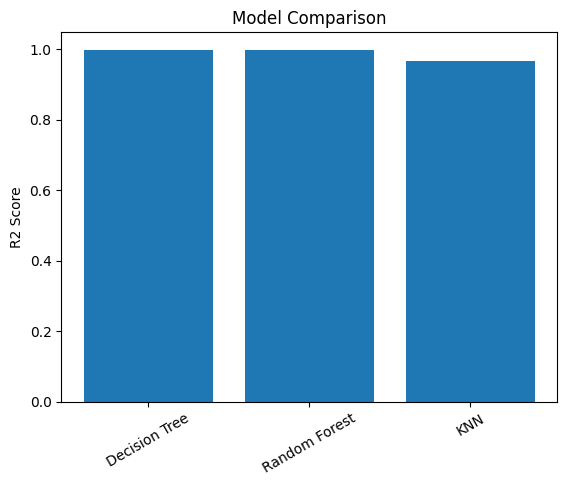

In [90]:
import matplotlib.pyplot as plt

plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xticks(rotation=30)
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

**Selecting the Best Performing Model**

In [91]:
best_model = results_df.sort_values(by="R2 Score", ascending=False).iloc[0]
print(best_model)

Model             Random Forest
MSE         41154272294552.3125
R2 Score                0.99842
Name: 1, dtype: object


**Training and Saving the Best Model**

In [92]:
import pickle

best_rf = RandomForestRegressor(n_estimators=100, max_depth=10)
best_rf.fit(X_train, y_train)

pickle.dump(best_rf, open("best_model.pkl", "wb"))

**Displaying Top 5 Movies Based on Predicted Score**

In [93]:
movies.columns

Index(['title', 'overview', 'genres', 'keywords', 'cast', 'tags'], dtype='object')

In [94]:
print(movies_data.shape)
print(similarity.shape)

(4803, 20)
(4803, 4803)


In [95]:
movies_data['prediction'] = similarity.sum(axis=1)

In [96]:
print(movies_data.columns)

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count', 'prediction'],
      dtype='object')


In [97]:
movies_data.sort_values(by="prediction", ascending=False)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,prediction
2428,17000000,"[{""id"": 80, ""name"": ""Crime""}, {""id"": 18, ""name...",NaN,26390,"[{""id"": 255, ""name"": ""male nudity""}, {""id"": 29...",en,Brooklyn's Finest,Enforcing the law within the notoriously rough...,18.790102,"[{""name"": ""Nu Image Films"", ""id"": 925}, {""name...",...,2009-01-16,29536299,133.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,This is War. This is Brooklyn.,Brooklyn's Finest,6.2,293,1024.901803
2442,17000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://darko.com/film_southlandtales.html,4723,"[{""id"": 236, ""name"": ""suicide""}, {""id"": 380, ""...",en,Southland Tales,Set in the futuristic landscape of Los Angeles...,9.349386,"[{""name"": ""Universal Pictures"", ""id"": 33}, {""n...",...,2006-05-15,374743,144.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Have a nice apocalypse.,Southland Tales,5.2,153,977.585981
2217,20000000,"[{""id"": 10402, ""name"": ""Music""}, {""id"": 35, ""n...",NaN,9716,"[{""id"": 90, ""name"": ""paris""}, {""id"": 110, ""nam...",en,Everyone Says I Love You,A New York girl sets her father up with a beau...,12.379781,"[{""name"": ""Miramax Films"", ""id"": 14}]",...,1996-12-06,0,101.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,,Everyone Says I Love You,6.5,147,959.770637
123,150000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""...",NaN,605,"[{""id"": 83, ""name"": ""saving the world""}, {""id""...",en,The Matrix Revolutions,The human city of Zion defends itself against ...,73.313918,"[{""name"": ""Village Roadshow Pictures"", ""id"": 7...",...,2003-11-05,424988211,129.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Everything that has a beginning has an end.,The Matrix Revolutions,6.4,3096,889.808859
1696,28000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10402, ""n...",http://www.straightouttacompton.com/,277216,"[{""id"": 380, ""name"": ""brother brother relation...",en,Straight Outta Compton,"In 1987, five young men, using brutally honest...",61.762330,"[{""name"": ""New Line Cinema"", ""id"": 12}, {""name...",...,2015-08-13,201634991,147.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Story of N.W.A.,Straight Outta Compton,7.7,1355,865.850991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4633,0,[],NaN,300327,[],en,Death Calls,An action-packed love story on the Mexican bor...,0.005883,[],...,2010-09-01,0,0.0,[],Released,,Death Calls,0.0,0,79.439454
3707,0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 35, ""nam...",http://www.privateperez.com/,66607,[],en,Salvando al Soldado Perez,La vida ha llevado a Julián Pérez por caminos ...,0.177356,[],...,2011-03-18,0,105.0,[],Released,,Saving Private Perez,6.1,18,56.545978
3686,0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10749, ""n...",NaN,40185,[],fr,Camping Sauvage,Un camping au bord d'un lac pendant les vacanc...,0.203230,[],...,2005-10-13,0,80.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""}]",Released,,Camping Sauvage,4.8,4,50.533285
4458,0,[],NaN,279759,[],en,Harrison Montgomery,Film from Daniel Davila,0.006943,[],...,2008-01-01,0,0.0,[],Released,,Harrison Montgomery,0.0,0,26.576931


In [98]:
model.fit(X_train.values, y_train)

predictions = model.predict(X.values)

print(predictions)

[1.83446707e+09 9.42409961e+08 8.92163521e+08 ... 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


**Content-Based Recommendation Function**

In [99]:
def recommend(movie):
    index = movies[movies['title'] == movie].index[0]
    distances = similarity[index]

    movies_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )

    for i in movies_list[1:6]:
        print(movies.iloc[i[0]].title)

**Displaying Unique Genres using Set**

In [100]:
genres_list = movies_data['genres'].tolist()

In [101]:
genres_list = []

for genre in movies_data['genres']:
    genres_list.extend(str(genre).split())

print(set(genres_list))

{'16,', '"Comedy"},', '"Comedy"}]', '12,', '"Science', '10770,', '"Crime"},', '35,', '"Thriller"}]', '"Mystery"},', '"name":', '18,', '10752,', '10402,', '80,', '10751,', '10769,', '99,', 'Fiction"},', '[]', '{"id":', '"Adventure"}]', '"Romance"}]', '"Documentary"}]', '"Adventure"},', '"Action"}]', '53,', 'Movie"}]', '"Fantasy"},', '9648,', '"War"}]', '"Mystery"}]', 'Fiction"}]', '"Drama"}]', '"Documentary"},', '"Romance"},', '"Music"},', '878,', '"Music"}]', '"TV', '"Western"},', '"Crime"}]', '"Family"},', '"Thriller"},', '"Horror"}]', '27,', '10749,', '[{"id":', '37,', '"Animation"}]', '"Fantasy"}]', '"Drama"},', '"Action"},', 'Movie"},', '36,', '"Horror"},', '"Family"}]', '"History"}]', '14,', '28,', '"Animation"},', '"Foreign"}]', '"Western"}]', '"History"},', '"Foreign"},', '"War"},'}


**Displaying Unique Sorted Genres**

In [102]:
print(sorted(set(genres_list)))

['"Action"},', '"Action"}]', '"Adventure"},', '"Adventure"}]', '"Animation"},', '"Animation"}]', '"Comedy"},', '"Comedy"}]', '"Crime"},', '"Crime"}]', '"Documentary"},', '"Documentary"}]', '"Drama"},', '"Drama"}]', '"Family"},', '"Family"}]', '"Fantasy"},', '"Fantasy"}]', '"Foreign"},', '"Foreign"}]', '"History"},', '"History"}]', '"Horror"},', '"Horror"}]', '"Music"},', '"Music"}]', '"Mystery"},', '"Mystery"}]', '"Romance"},', '"Romance"}]', '"Science', '"TV', '"Thriller"},', '"Thriller"}]', '"War"},', '"War"}]', '"Western"},', '"Western"}]', '"name":', '10402,', '10749,', '10751,', '10752,', '10769,', '10770,', '12,', '14,', '16,', '18,', '27,', '28,', '35,', '36,', '37,', '53,', '80,', '878,', '9648,', '99,', 'Fiction"},', 'Fiction"}]', 'Movie"},', 'Movie"}]', '[]', '[{"id":', '{"id":']


**Counting Genre Frequency**

In [103]:
from collections import Counter

genre_count = Counter(genres_list)
print(genre_count)

Counter({'"name":': 12160, '{"id":': 7385, '[{"id":': 4775, '18,': 2297, '35,': 1722, '"Drama"},': 1503, '53,': 1274, '"Comedy"},': 1211, '28,': 1154, '"Action"},': 1045, '10749,': 894, '"Thriller"}]': 826, '"Drama"}]': 794, '12,': 790, '80,': 696, '"Adventure"},': 679, '"Romance"}]': 676, '878,': 535, '"Science': 535, '27,': 519, '10751,': 513, '"Comedy"}]': 511, '"Crime"},': 450, '"Thriller"},': 448, '14,': 424, '"Horror"},': 361, '9648,': 348, 'Fiction"}]': 298, '"Fantasy"},': 290, '"Family"}]': 280, '"Crime"}]': 246, 'Fiction"},': 237, '16,': 234, '"Family"},': 233, '"Romance"},': 218, '"Animation"},': 213, '"Mystery"},': 210, '36,': 197, '10402,': 185, '"Horror"}]': 158, '10752,': 144, '"Mystery"}]': 138, '"Fantasy"}]': 134, '"Adventure"}]': 111, '99,': 110, '"Action"}]': 109, '"History"},': 109, '"War"}]': 109, '"Music"}]': 103, '"History"}]': 88, '"Documentary"}]': 84, '37,': 82, '"Music"},': 82, '"Western"}]': 62, '"War"},': 35, '10769,': 34, '[]': 28, '"Documentary"},': 26, '"

**Creating Genre DataFrame**

In [104]:
genre_df = pd.DataFrame({
    "Genre": list(set(genres_list))
})

print(genre_df.sort_values(by="Genre"))

            Genre
52     "Action"},
25     "Action"}]
24  "Adventure"},
21  "Adventure"}]
60  "Animation"},
..            ...
53       Movie"},
27       Movie"}]
19             []
47        [{"id":
20         {"id":

[66 rows x 1 columns]


**Extracting and Cleaning Genre Information**

In [105]:
import ast

def extract_genres(obj):
    return [i['name'] for i in ast.literal_eval(obj)]

movies_data['genres_clean'] = movies_data['genres'].apply(extract_genres)

print(movies_data[['title', 'genres_clean']].head())

                                      title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre   
3                     The Dark Knight Rises   
4                               John Carter   

                                    genres_clean  
0  [Action, Adventure, Fantasy, Science Fiction]  
1                   [Adventure, Fantasy, Action]  
2                     [Action, Adventure, Crime]  
3               [Action, Crime, Drama, Thriller]  
4           [Action, Adventure, Science Fiction]  


In [106]:
movies_data['genres_clean'] = movies_data['genres'].apply(extract_genres)

In [107]:
import ast

def extract_genres(obj):
    return [i['name'] for i in ast.literal_eval(obj)]

movies_data['genres_clean'] = movies_data['genres'].apply(extract_genres)

# get all genres
all_genres = sum(movies_data['genres_clean'], [])

print(sorted(set(all_genres)))

['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


**Basic Genre-Based Recommendation Function**

In [108]:
def recommend_by_genre(genre, top_n=5):

    filtered = data[data['genres_clean'].apply(lambda x: genre in x)]

    filtered = filtered.sort_values(by='popularity', ascending=False)

    return filtered[['title', 'genres_clean', 'popularity']].head(top_n)

**Final Output of Genre-Based Recommendation System**

In [109]:
filtered = movies_data[movies_data['genres_clean'].apply(lambda x: genre in x)]

**Improved Genre-Based Recommendation Function**

In [110]:
def recommend_by_genre(genre, top_n=5):

    genre = genre.lower()

    filtered = data[data['genres_clean'].apply(
        lambda x: any(genre == g.lower() for g in x)
    )]

    filtered = filtered.sort_values(by='popularity', ascending=False)

    return filtered[['title', 'genres_clean', 'popularity']].head(top_n)

**Multi-Genre Recommendation using Flexible Matching**

In [111]:
def recommend_multiple_genres(genres, top_n=5):
    genres = [g.lower() for g in genres]

    filtered = movies_data[
        movies_data['genres_clean'].apply(
            lambda x: any(
                g.lower() in [i.lower() for i in x]
                for g in genres
            )
        )
    ]

    filtered = filtered.sort_values(
        by='popularity',
        ascending=False
    )

    return filtered[['title', 'genres_clean', 'popularity']].head(top_n)

**Displaying Multi-Genre Recommendation Output**

In [112]:
recommend_multiple_genres(["Fantasy", "Adventure"])

,title,genres_clean,popularity
546,Minions,"[Family, Animation, Adventure, Comedy]",875.581305
95,Interstellar,"[Adventure, Drama, Science Fiction]",724.247784
788,Deadpool,"[Action, Adventure, Comedy]",514.569956
94,Guardians of the Galaxy,"[Action, Science Fiction, Adventure]",481.098624
127,Mad Max: Fury Road,"[Action, Adventure, Science Fiction, Thriller]",434.278564


**Implementation of Genre-Based Recommendation Function**

In [113]:
def recommend_by_genre(genre, top_n=5):

    filtered = data[data['genres_clean'].apply(lambda x: genre in x)]

    filtered = filtered.sort_values(by=['vote_average', 'popularity'], ascending=False)

    return filtered[['title', 'vote_average', 'popularity']].head(top_n)

**Displaying Genre-Based Recommendation Output**

In [114]:
def recommend_by_genre(genre, top_n=5):

    filtered = movies_data[
        movies_data['genres_clean'].apply(
            lambda x: genre in x
        )
    ]

    filtered = filtered.sort_values(
        by=['vote_average', 'popularity'],
        ascending=False
    )

    return filtered[['title', 'genres_clean', 'vote_average', 'popularity']].head(top_n)

In [115]:
recommend_by_genre("History")

,title,genres_clean,vote_average,popularity
2386,One Man's Hero,"[Western, Action, Drama, History]",9.3,0.910529
1818,Schindler's List,"[Drama, History, War]",8.3,104.469351
2947,The Visual Bible: The Gospel of John,"[Drama, History]",8.2,3.208172
2522,The Imitation Game,"[History, Drama, Thriller, War]",8.0,145.364591
2105,12 Years a Slave,"[Drama, History]",7.9,95.922900


In [116]:
recommend_by_genre("Adventure")

,title,genres_clean,vote_average,popularity
2796,The Prisoner of Zenda,"[Adventure, Drama, Romance]",8.4,4.021389
2294,Spirited Away,"[Fantasy, Adventure, Animation, Family]",8.3,118.968562
1990,The Empire Strikes Back,"[Adventure, Action, Science Fiction]",8.2,78.517830
2247,Princess Mononoke,"[Adventure, Fantasy, Animation]",8.2,60.732738
1987,Howl's Moving Castle,"[Fantasy, Animation, Adventure]",8.2,49.549984


In [117]:
recommend_by_genre("Fantasy")

,title,genres_clean,vote_average,popularity
2294,Spirited Away,"[Fantasy, Adventure, Animation, Family]",8.3,118.968562
690,The Green Mile,"[Fantasy, Drama, Crime]",8.2,103.698022
2247,Princess Mononoke,"[Adventure, Fantasy, Animation]",8.2,60.732738
1987,Howl's Moving Castle,"[Fantasy, Animation, Adventure]",8.2,49.549984
329,The Lord of the Rings: The Return of the King,"[Adventure, Fantasy, Action]",8.1,123.630332


In [118]:
recommend_by_genre("Romance")

,title,genres_clean,vote_average,popularity
4247,Me You and Five Bucks,"[Romance, Comedy, Drama]",10.0,0.094105
2796,The Prisoner of Zenda,"[Adventure, Drama, Romance]",8.4,4.021389
809,Forrest Gump,"[Comedy, Drama, Romance]",8.2,138.133331
3906,The Apartment,"[Comedy, Drama, Romance]",8.1,22.889294
3041,Love Jones,"[Comedy, Drama, Romance]",8.1,1.000178
